In [1]:
import camelot
import pandas as pd

grant_lattice = camelot.read_pdf("data/B057_all.pdf", pages="all", flavor="lattice", suppress_stdout=False)

collect_grant = pd.DataFrame({0: [],
                              1: [],
                              2: [],
                              3: [],
                              4: []})

for page in grant_lattice:
    collect_grant = pd.concat([collect_grant, page.df], ignore_index=True)

collect_grant.tail(10)

,0,1,2,3,4
4949,13,003920347,АУБАКИРОВА ДИЛЯРА РУСТЕМОВНА,125,522
4950,14,003565700,КЕНЖЕБАЙҚЫЗЫ ӘСЕЛ,125,021
4951,15,003921608,ДӘУЛЕТҚАНОВ СЫРЫМ ДӘУРЕНҰЛЫ,124,522
4952,16,003920305,САГИДОЛДА САЯЖАН \nДЖАМБУЛАТОВНА,124,522
4953,17,003464924,МҰСАҒАЗЫ ДУМАН ЕРІКҰЛЫ,123,013
4954,18,003479507,ГАЯЗОВ ТИМУР АЛЕКСАНДРОВИЧ,123,013
4955,19,003731357,БУКРЕЕВ ДМИТРИЙ АЛЕКСАНДРОВИЧ,122,027
4956,20,003597325,АХМЕТЖАНОВА КИРА ГЕННАДЬЕВНА,121,057
4957,21,003526436,ТАЗИТДИНОВ РИФАТ ИЛЬДАНОВИЧ,121,522
4958,22,003645188,ЛИМОН ИЛЬЯ АЛЕКСАНДРОВИЧ,121,522


In [2]:
# for rollback the table
collect_grant = pd.DataFrame({0: [],
                              1: [],
                              2: [],
                              3: [],
                              4: []})

for page in grant_lattice:
    collect_grant = pd.concat([collect_grant, page.df], ignore_index=True)

In [3]:
# column renaming
collect_grant.rename(columns={0:"#",1:"id",2:"name",3:"score",4:"university"}, inplace=True) 


#### Cleaning | Parsing

In [4]:
collect_grant["name"] = collect_grant["name"].str.replace("\n","")
collect_grant["#"] = collect_grant["#"].str.replace("\n","")
collect_grant.tail(20)

,#,id,name,score,university
4939,3,003919932,КУСТАВЛЕТОВ САНЖАР МАРАТОВИЧ,135,522
4940,4,003920352,ГУСМАНОВА КАУСАР АСЫЛБЕКОВНА,135,027
4941,5,003921700,ҚҰРМАНҒАЗЫ ӘЛИӘМІР АРМАНҰЛЫ,134,522
4942,6,003921703,МЫРЗАТАЕВ НҰРБЕК НҰРЖАНҰЛЫ,132,522
4943,7,003920667,ТОЛБАЕВ АЛИНУР АБУЛХАИРҰЛЫ,131,522
4944,8,003921060,СЕЙТКАЛИ ДӘУРЕН МЕЙРБЕКҰЛЫ,130,522
4945,9,003920506,ГУСЕЙНОВ АЛИХАН ШАМИСТАН ОГЛЫ,127,522
4946,10,003811731,ТУГУШЕВ МАКСИМ АЛЕКСАНДРОВИЧ,126,029
4947,11,003919671,ҚУАНЫШ АЯН АЗАМАТҰЛЫ,126,522
4948,12,003483362,МЫРЗАБЕК НҰРТУҒАН ҒАЛЫМҰЛЫ,125,027


In [ ]:
for i, row in collect_grant.iterrows():
    if row["#"] == "":
        collect_grant.loc[i-1, "name"] += " " + collect_grant.loc[i,"name"]
        collect_grant.drop(i, inplace=True)
    elif len(row["#"]) >=7:
        collect_grant.drop(i, inplace=True) 

#### Sharing

In [11]:
collect_grant.to_csv("data/grants_B057.csv", index=False)

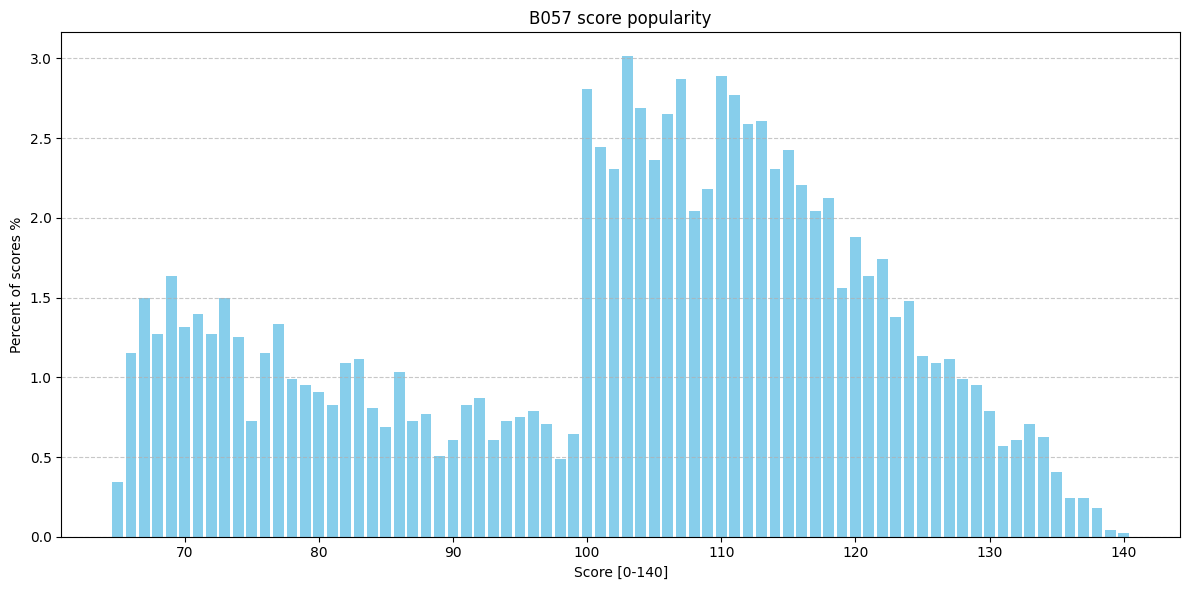

In [12]:
import matplotlib.pyplot as plt

parsed_grants = pd.read_csv("data/grants_B057.csv")

x = parsed_grants["score"].drop_duplicates()
y = parsed_grants["score"].value_counts(sort=False)/sum(parsed_grants["score"].value_counts(sort=False))*100

plt.figure(figsize=(12, 6))
plt.bar(x,y , color='skyblue')
plt.title('B057 score popularity')
plt.xlabel('Score [0-140]')
plt.ylabel('Percent of scores %')
plt.xticks()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
parsed_grants["score"].value_counts()

score
103    149
110    143
107    142
100    139
111    137
      ... 
137     12
136     11
138      9
139      2
140      1
Name: count, Length: 76, dtype: int64